# **Configurations**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import sys

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/College/FLEX-Med/flex-med

# Dependency Installation
!pip install fastapi uvicorn pyngrok nest-asyncio flwr["simulation"] -q

PROJECT_ROOT = "/content/drive/MyDrive/College/FLEX-Med/flex-med"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import flex_med
print("flex_med loaded from:", flex_med.__file__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/College/FLEX-Med/flex-med
flex_med loaded from: /content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/__init__.py


# **Verify if the environment is setup for FL simulation**

In [4]:
#!/usr/bin/env python3
"""
FL Health Verification Script (Jupyter / Colab Safe)

This version is safe to run inside:
- Jupyter Notebook
- Google Colab
- Local terminal (python verify_fl_health.py)

It avoids __file__ and resolves paths dynamically.
"""

import os
import json
import sys
from pathlib import Path
from typing import Dict, List, Tuple

# =====================================================
# PROJECT ROOT RESOLUTION (JUPYTER SAFE)
# =====================================================
# Assumes notebook is launched from flex-med root
PROJECT_ROOT = Path.cwd()

# If flex_med is not importable, auto-fix sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# =====================================================
# ANSI COLORS
# =====================================================
class Colors:
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BLUE = '\033[94m'
    BOLD = '\033[1m'
    END = '\033[0m'


def print_header(text: str):
    print(f"\n{Colors.BOLD}{Colors.BLUE}{'=' * 70}{Colors.END}")
    print(f"{Colors.BOLD}{Colors.BLUE}{text.center(70)}{Colors.END}")
    print(f"{Colors.BOLD}{Colors.BLUE}{'=' * 70}{Colors.END}\n")


def print_success(text: str):
    print(f"{Colors.GREEN}✓ {text}{Colors.END}")


def print_warning(text: str):
    print(f"{Colors.YELLOW}⚠ {text}{Colors.END}")


def print_error(text: str):
    print(f"{Colors.RED}✗ {text}{Colors.END}")


def print_info(text: str):
    print(f"  {text}")


# =====================================================
# DATASET CHECK
# =====================================================
def check_dataset_structure(
    dataset_path: Path,
    expected_classes: List[str] = ["all", "hem"]
) -> Tuple[bool, Dict]:

    stats = {}

    if not dataset_path.exists():
        return False, {"error": "Dataset path does not exist"}

    for class_name in expected_classes:
        class_path = dataset_path / class_name
        if not class_path.exists():
            return False, {"error": f"Missing class directory: {class_name}"}

        image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        images = [f for f in class_path.iterdir() if f.suffix.lower() in image_exts]
        stats[class_name] = len(images)

    total = sum(stats.values())
    if total == 0:
        return False, {"error": "No images found in dataset"}

    for cls in expected_classes:
        stats[f"{cls}_pct"] = stats[cls] / total * 100

    stats["total"] = total
    return True, stats


def verify_datasets(use_colab: bool = True) -> bool:
    print_header("Step 1: Dataset Integrity Check")

    if use_colab:
        base_path = Path("/content/drive/MyDrive/College/FLEX-Med/cnmc_datasets")
    else:
        base_path = PROJECT_ROOT / "cnmc_datasets"

    datasets = {
        "Client 0": base_path / "cnmc_client_0",
        "Client 1": base_path / "cnmc_client_1",
        "Public Anchor": base_path / "cnmc_public_anchor",
        "Public Test": base_path / "cnmc_public_test",
    }

    all_valid = True

    for name, path in datasets.items():
        valid, stats = check_dataset_structure(path)
        if valid:
            print_success(f"{name}: {path}")
            print_info(f"Total images: {stats['total']}")
            print_info(f"  Leukemia (all): {stats['all']} ({stats['all_pct']:.1f}%)")
            print_info(f"  Healthy (hem):  {stats['hem']} ({stats['hem_pct']:.1f}%)")
        else:
            print_error(f"{name}: {path}")
            print_info(f"  Error: {stats.get('error')}")
            all_valid = False

    return all_valid


# =====================================================
# CLIENT CONFIG CHECK
# =====================================================
def verify_client_config() -> bool:
    print_header("Step 2: Client Configuration Check")

    config_path = PROJECT_ROOT / "cnmc_data.json"

    if not config_path.exists():
        print_error(f"Configuration file not found: {config_path}")
        return False

    with open(config_path) as f:
        clients = json.load(f)

    print_success(f"Loaded config: {config_path}")
    print_info(f"Number of clients: {len(clients)}")

    for client in clients:
        print_info(f"\n  Client {client['id']}: {client['client_name']}")
        print_info(f"    Model: {client['model_type']}")

        if client['has_local_data']:
            path = Path(client['dataset_path'])
            if path.exists():
                print_success(f"    Dataset exists")
            else:
                print_error(f"    Dataset missing: {path}")
                return False

        model_path = Path(client['model_path'])
        if model_path.exists():
            print_warning("    Existing model checkpoint found")
        else:
            print_success("    Fresh training (no checkpoint)")

    return True


# =====================================================
# FL CONFIG CHECK
# =====================================================
def verify_fl_config() -> bool:
    print_header("Step 3: FL Configuration Parameters")

    config_path = PROJECT_ROOT / "pyproject.toml"

    if not config_path.exists():
        print_error("pyproject.toml not found")
        return False

    content = config_path.read_text()
    params = {}

    for line in content.splitlines():
        if '=' in line and not line.strip().startswith('#'):
            k, v = line.split('=', 1)
            params[k.strip()] = v.split('#')[0].strip()

    print_success("FL config loaded")
    print_info(f"Rounds: {params.get('num-server-rounds')}")
    print_info(f"Local epochs: {params.get('local-epochs')}")
    print_info(f"Batch size: {params.get('batch-size')}")
    print_info(f"LR: {params.get('lr')}")

    lr_decay = float(params.get('lr-decay', 0))
    if lr_decay == 0.98:
        print_success("LR decay = 0.98 ✓")
    else:
        print_warning(f"LR decay = {lr_decay} (expected 0.98)")

    return True

# =====================================================
# CLEAN STATE
# =====================================================
def verify_clean_state(use_colab: bool = True) -> bool:
    print_header("Step 5: Clean State Verification")

    models_dir = (
        Path("/content/drive/MyDrive/College/models")
        if use_colab
        else PROJECT_ROOT / "models"
    )

    if not models_dir.exists():
        print_success("No existing models directory (fresh)")
        return True

    checkpoints = list(models_dir.glob("*.pt"))
    if checkpoints:
        print_warning(f"Found {len(checkpoints)} checkpoint(s)")
    else:
        print_success("No checkpoints found")

    return True


# =====================================================
# MAIN
# =====================================================
def main():
    print(f"\n{Colors.BOLD}FL Health Verification Tool (Notebook Mode){Colors.END}")

    results = [
        verify_datasets(use_colab=True),
        verify_client_config(),
        verify_fl_config(),
        verify_clean_state(use_colab=True),
    ]

    print_header("Verification Summary")

    if all(results):
        print_success("All checks passed — Ready for FL simulation 🚀")
    else:
        print_error("Some checks failed — Fix issues before training")


# Run immediately in notebook
main()


FL Health Verification Tool (Notebook Mode)

                   Step 1: Dataset Integrity Check                    

✓ Client 0: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_client_0
  Total images: 4387
    Leukemia (all): 3332 (76.0%)
    Healthy (hem):  1055 (24.0%)
✓ Client 1: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_client_1
  Total images: 4386
    Leukemia (all): 3282 (74.8%)
    Healthy (hem):  1104 (25.2%)
✓ Public Anchor: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_public_anchor
  Total images: 2504
    Leukemia (all): 1252 (50.0%)
    Healthy (hem):  1252 (50.0%)
✓ Public Test: /content/drive/MyDrive/College/FLEX-Med/cnmc_datasets/cnmc_public_test
  Total images: 1252
    Leukemia (all): 626 (50.0%)
    Healthy (hem):  626 (50.0%)

                  Step 2: Client Configuration Check                  

✓ Loaded config: /content/drive/MyDrive/College/FLEX-Med/flex-med/cnmc_data.json
  Number of clients: 2
  
  Client 26: Asiri-r

# **API Definition**

In [4]:
import os
import sys
import json
import logging
import subprocess
from typing import List, Tuple
import re
from datetime import datetime

from fastapi import FastAPI, BackgroundTasks, HTTPException
from pydantic import BaseModel
from starlette.middleware.cors import CORSMiddleware

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================

# Import configuration from config.py
try:
    from flex_med.utils.config import (
        PROJECT_DIR,
        LOG_FILE_PATH,
        SIMULATION_LOG_PATH,
        DATA_JSON_PATH,
        PYPROJECT_PATH,
        RUN_SIMULATION_SHELL_FILE_PATH,
        SIMULATION_STATUS_JSON_FILE_PATH
    )
except ImportError:
    import sys
    sys.path.append(os.getcwd())
    from flex_med.utils.config import (
        PROJECT_DIR,
        LOG_FILE_PATH,
        SIMULATION_LOG_PATH,
        DATA_JSON_PATH,
        PYPROJECT_PATH,
        RUN_SIMULATION_SHELL_FILE_PATH,
        SIMULATION_STATUS_JSON_FILE_PATH
    )

os.makedirs(PROJECT_DIR, exist_ok=True)

# ==========================================
# 2. SERVER LOGGING SETUP
# ==========================================

logger = logging.getLogger("inference_logger")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

file_handler = logging.FileHandler(LOG_FILE_PATH)
stream_handler = logging.StreamHandler(sys.stdout)

formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
file_handler.setFormatter(formatter)
stream_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(stream_handler)

logger.info("=== Flex-Med Orchestrator Started ===")

# ==========================================
# 3. CONFIGURATION VALIDATION
# ==========================================

def validate_client_config(client) -> Tuple[bool, str]:
    """
    Validate client configuration

    Returns:
        (is_valid, error_message)
    """
    valid_models = [
        'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152',
        'mobilenet_v2', 'mobilenet_v3_small', 'mobilenet_v3_large',
        'densenet121', 'densenet161', 'densenet169', 'densenet201',
        'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3',
        'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7',
        'vgg11', 'vgg13', 'vgg16', 'vgg19',
        'alexnet', 'squeezenet', 'inception_v3', 'googlenet'
    ]
    if client.model_type not in valid_models:
        return False, f"Invalid model type: {client.model_type}. Must be one of {valid_models}"

    if client.has_local_data:
        if not client.dataset_path:
            return False, f"Client {client.client_name} has_local_data=True but no dataset_path"
        if not os.path.exists(client.dataset_path):
            return False, f"Dataset path does not exist: {client.dataset_path}"

    if not client.model_path:
        return False, f"Client {client.client_name} has no model_path"

    model_dir = os.path.dirname(client.model_path)
    if not os.path.exists(model_dir):
        try:
            os.makedirs(model_dir, exist_ok=True)
            logger.info(f"Created model directory: {model_dir}")
        except Exception as e:
            return False, f"Cannot create model directory: {model_dir}, error: {e}"

    return True, ""

# ==========================================
# 4. CREATE RUN SCRIPT
# ==========================================

def create_run_script():
    """Creates the shell script that runs the Flower simulation."""
    script_content = f"""#!/bin/bash
cd "{PROJECT_DIR}"

echo "[Script] Starting Flex-Med Simulation at $(date)..."

# Only install the local package in editable mode (Fast & Lightweight)
pip install -e . -q

# Run Flower CLI directly
flwr run .
"""

    with open(RUN_SIMULATION_SHELL_FILE_PATH, "w") as f:
        f.write(script_content)

    os.chmod(RUN_SIMULATION_SHELL_FILE_PATH, 0o755)
    logger.info(f"Created run_simulation.sh at {RUN_SIMULATION_SHELL_FILE_PATH}")

    return RUN_SIMULATION_SHELL_FILE_PATH

SCRIPT_PATH = create_run_script()

# ==========================================
# 5. BACKGROUND TASK
# ==========================================

def run_simulation_task():
    """Runs the FL simulation in background."""
    logger.info("="*70)
    logger.info("Starting Flower Simulation in Background")
    logger.info("="*70)

    try:
        logger.info("\n[Background Task] Running Flower Simulation...")

        with open(SIMULATION_LOG_PATH, "w") as log_file:
            process = subprocess.run(
                ["bash", SCRIPT_PATH],
                stdout=log_file,
                stderr=log_file,
                text=True
            )

        return_code = process.returncode

        if return_code == 0:
            logger.info("\n" + "="*70)
            logger.info("✅ Federated Learning Simulation COMPLETED Successfully")
            logger.info("="*70)

            completion_status = {
                "status": "completed",
                "timestamp": datetime.now().isoformat(),
                "return_code": return_code,
                "log_path": SIMULATION_LOG_PATH
            }


            with open(SIMULATION_STATUS_JSON_FILE_PATH, 'w') as f:
                json.dump(completion_status, f, indent=2)

            logger.info(f"✅ Status saved to: {SIMULATION_STATUS_JSON_FILE_PATH}")

        else:
            logger.error("\n" + "="*70)
            logger.error(f"❌ Federated Learning Simulation FAILED")
            logger.error(f"   Return Code: {return_code}")
            logger.error("="*70)

            error_status = {
                "status": "failed",
                "timestamp": datetime.now().isoformat(),
                "return_code": return_code,
                "error": "Simulation failed",
                "log_path": SIMULATION_LOG_PATH
            }


            with open(SIMULATION_STATUS_JSON_FILE_PATH, 'w') as f:
                json.dump(error_status, f, indent=2)

    except Exception as e:
        logger.error(f"\n❌ Simulation error: {e}")
        import traceback
        logger.error(traceback.format_exc())

        try:
            error_status = {
                "status": "exception",
                "timestamp": datetime.now().isoformat(),
                "error": str(e),
                "traceback": traceback.format_exc(),
                "log_path": SIMULATION_LOG_PATH
            }

            with open(SIMULATION_STATUS_JSON_FILE_PATH, 'w') as f:
                json.dump(error_status, f, indent=2)
        except:
            pass

# ==========================================
# 6. PYDANTIC MODELS
# ==========================================

class ClientConfig(BaseModel):
    id: int
    created_at: str
    client_name: str
    model_type: str
    dataset_path: str | None
    status: str
    has_local_data: bool
    model_path: str
    metrics: str

# ==========================================
# 7. FASTAPI APP
# ==========================================

app = FastAPI(title="Flex-Med Orchestrator")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==========================================
# 8. ENDPOINTS
# ==========================================

@app.get("/")
def read_root():
    return {"message": "Flex-Med Orchestrator is running"}

def update_data_json(clients: List[ClientConfig], path: str = DATA_JSON_PATH):
    """Save client configuration to data.json"""
    try:
        client_dicts = [c.dict() for c in clients]
        os.makedirs(os.path.dirname(path), exist_ok=True)

        with open(path, "w") as f:
            json.dump(client_dicts, f, indent=2)

        logger.info(f"✓ Updated data.json with {len(clients)} clients")
        return True
    except Exception as e:
        logger.error(f"Failed to update data.json: {e}")
        return False

def update_pyproject_toml(num_clients: int, path: str = PYPROJECT_PATH):
    """Update pyproject.toml with correct num-supernodes"""
    try:
        if not os.path.exists(path):
            logger.error(f"pyproject.toml not found at {path}")
            return False

        with open(path, 'r') as f:
            content = f.read()

        pattern = r'(options\.num-supernodes\s*=\s*)\d+'

        if not re.search(pattern, content):
            logger.warning("num-supernodes not found in pyproject.toml")
            return False

        old_match = re.search(r'options\.num-supernodes\s*=\s*(\d+)', content)
        old_value = old_match.group(1) if old_match else "unknown"

        new_content = re.sub(pattern, f'\\g<1>{num_clients}', content)

        with open(path, 'w') as f:
            f.write(new_content)

        logger.info(f"✓ Updated pyproject.toml: num-supernodes {old_value} → {num_clients}")
        return True

    except Exception as e:
        logger.error(f"Failed to update pyproject.toml: {e}")
        return False

@app.post("/start_fl")
async def start_fl(
    clients: List[ClientConfig],
    background_tasks: BackgroundTasks,
):
    """
    Start federated learning simulation with dynamic client configuration.

    This endpoint:
    1. Validates client configurations
    2. Saves client config to data.json
    3. Updates pyproject.toml with correct num-supernodes
    4. Triggers the FL simulation in background
    """

    num_clients = len(clients)
    logger.info(f"=" * 70)
    logger.info(f"Received FL start request for {num_clients} clients")
    logger.info(f"=" * 70)

    # Log client details
    for i, client in enumerate(clients):
        data_status = "Has Data" if client.has_local_data else "Free Rider"
        logger.info(f"  Client {i}: {client.client_name:20} | {client.model_type:15} | {data_status}")

    # ===== VALIDATION: CHECK CLIENT CONFIGS =====
    logger.info("\n[Endpoint] Validating client configurations...")

    validation_errors = []
    for i, client in enumerate(clients):
        is_valid, error_msg = validate_client_config(client)
        if not is_valid:
            validation_errors.append(f"Client {i}: {error_msg}")

    if validation_errors:
        error_detail = "\n".join(validation_errors)
        logger.error(f"Configuration validation failed:\n{error_detail}")
        raise HTTPException(
            status_code=400,
            detail=f"Invalid client configuration:\n{error_detail}"
        )

    logger.info("✓ All client configurations validated")

    # ===== STEP 1: UPDATE DATA.JSON =====
    logger.info("\n[Endpoint] Step 1: Updating data.json...")

    if not update_data_json(clients, DATA_JSON_PATH):
        raise HTTPException(
            status_code=500,
            detail="Failed to save client configuration to data.json"
        )

    # ===== STEP 2: UPDATE PYPROJECT.TOML =====
    logger.info("\n[Endpoint] Step 2: Updating pyproject.toml...")

    if not update_pyproject_toml(num_clients, PYPROJECT_PATH):
        logger.warning("Failed to update pyproject.toml, but continuing...")

    # ===== STEP 3: CREATE RUN SCRIPT =====
    logger.info("\n[Endpoint] Step 3: Creating run script...")
    global SCRIPT_PATH
    SCRIPT_PATH = create_run_script()

    # ===== STEP 4: TRIGGER SIMULATION =====
    logger.info("\n[Endpoint] Step 4: Starting FL simulation...")
    logger.info(f"  - Number of clients: {num_clients}")
    logger.info(f"  - Active participants: {sum(1 for c in clients if c.has_local_data)}")
    logger.info(f"  - Free riders: {sum(1 for c in clients if not c.has_local_data)}")
    logger.info(f"=" * 70 + "\n")

    # Trigger the background task
    background_tasks.add_task(run_simulation_task)

    return {
        "status": "accepted",
        "message": f"Federated simulation started with {num_clients} clients",
        "num_clients": num_clients,
        "active_participants": sum(1 for c in clients if c.has_local_data),
        "free_riders": sum(1 for c in clients if not c.has_local_data),
        "config_updated": {
            "data_json": DATA_JSON_PATH,
            "pyproject_toml": PYPROJECT_PATH
        },
        "log_path": SIMULATION_LOG_PATH
    }

print("✅ Flex-Med Orchestrator Ready")

2026-01-21 20:06:58,060 - INFO - === Flex-Med Orchestrator Started ===


INFO:inference_logger:=== Flex-Med Orchestrator Started ===


2026-01-21 20:06:59,440 - INFO - Created run_simulation.sh at /content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/utils/run_simulation.sh


INFO:inference_logger:Created run_simulation.sh at /content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/utils/run_simulation.sh


✅ Flex-Med Orchestrator Ready


# **NGROK Setup**

In [5]:
import nest_asyncio
import uvicorn
import subprocess
import threading
from pyngrok import ngrok
from pyngrok.process import kill_process
from fastapi import FastAPI, BackgroundTasks, HTTPException
from starlette.middleware.cors import CORSMiddleware

# 0. Cleanup
try:
    ngrok.disconnect()
    kill_process()
except:
    pass

# 1. Auth & Tunnel
# REPLACE WITH YOUR ACTUAL TOKEN
AUTH_TOKEN = "2nI3IUybQHGO30McAH7x4UJRiND_695D6z3DbKjWLrq7N1ATy"
ngrok.set_auth_token(AUTH_TOKEN)

http_tunnel = ngrok.connect(8000)
public_url = http_tunnel.public_url

print(f"🌐 API URL: {public_url}")
print(f"🚀 POST to start FL: {public_url}/start_fl")

# 2. Run Uvicorn
nest_asyncio.apply()

def run_uvicorn():
    uvicorn.run(app, port=8000, host="0.0.0.0")

thread = threading.Thread(target=run_uvicorn)
thread.start()

🌐 API URL: https://3a91f17c99b5.ngrok-free.app
🚀 POST to start FL: https://3a91f17c99b5.ngrok-free.app/start_fl


# **View Training Logs**

In [6]:
!tail -f "/content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/utils/simulation_run.log"

[Script] Starting Flex-Med Simulation at Wed Jan 21 08:07:54 PM UTC 2026...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 140.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/2

INFO:inference_logger:


2026-01-21 23:42:42,200 - INFO - ✅ Federated Learning Simulation COMPLETED Successfully


INFO:inference_logger:✅ Federated Learning Simulation COMPLETED Successfully


2026-01-21 23:42:42,202 - INFO - ======================================================================


INFO:inference_logger:======================================================================


2026-01-21 23:42:42,685 - INFO - ✅ Status saved to: /content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/utils/simulation_status.json


INFO:inference_logger:✅ Status saved to: /content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/utils/simulation_status.json


^C


# **Kill process**

In [ ]:
# Kill any process running on port 8000
!fuser -k 8000/tcp

print("Attempted to kill processes on port 8000. Please re-run the FastAPI server cell now.")

# **FL Simulation Evaluation**


FLEX-Med FL Training Summary

[0] Asiri-resnet-allidb2 (resnet18)
--------------------------------------------------
  Evaluation Strategy: HYBRID
  Rounds completed: 5

  GLOBAL METRICS (Public Test Dataset):
    Pre-FL  (Centralized): Acc=50.00%, Loss=1.402
    Post-FL (Federated):   Acc=74.76%, Loss=0.657
    FL Benefit:            Acc=+24.76%, Loss=-0.746

  FINAL METRICS:
    Accuracy:   74.76%
    F1 Score:   0.768
    Precision:  0.711
    Recall:     0.835
    Class Gap:  17.57%

[1] Durdans-mobilenet-cnmc (mobilenet_v2)
--------------------------------------------------
  Evaluation Strategy: HYBRID
  Rounds completed: 5

  GLOBAL METRICS (Public Test Dataset):
    Pre-FL  (Centralized): Acc=50.00%, Loss=0.693
    Post-FL (Federated):   Acc=72.76%, Loss=0.639
    FL Benefit:            Acc=+22.76%, Loss=-0.054

  FINAL METRICS:
    Accuracy:   72.76%
    F1 Score:   0.759
    Precision:  0.680
    Recall:     0.859
    Class Gap:  26.36%



FLEX-Med FL Evaluation - Generating

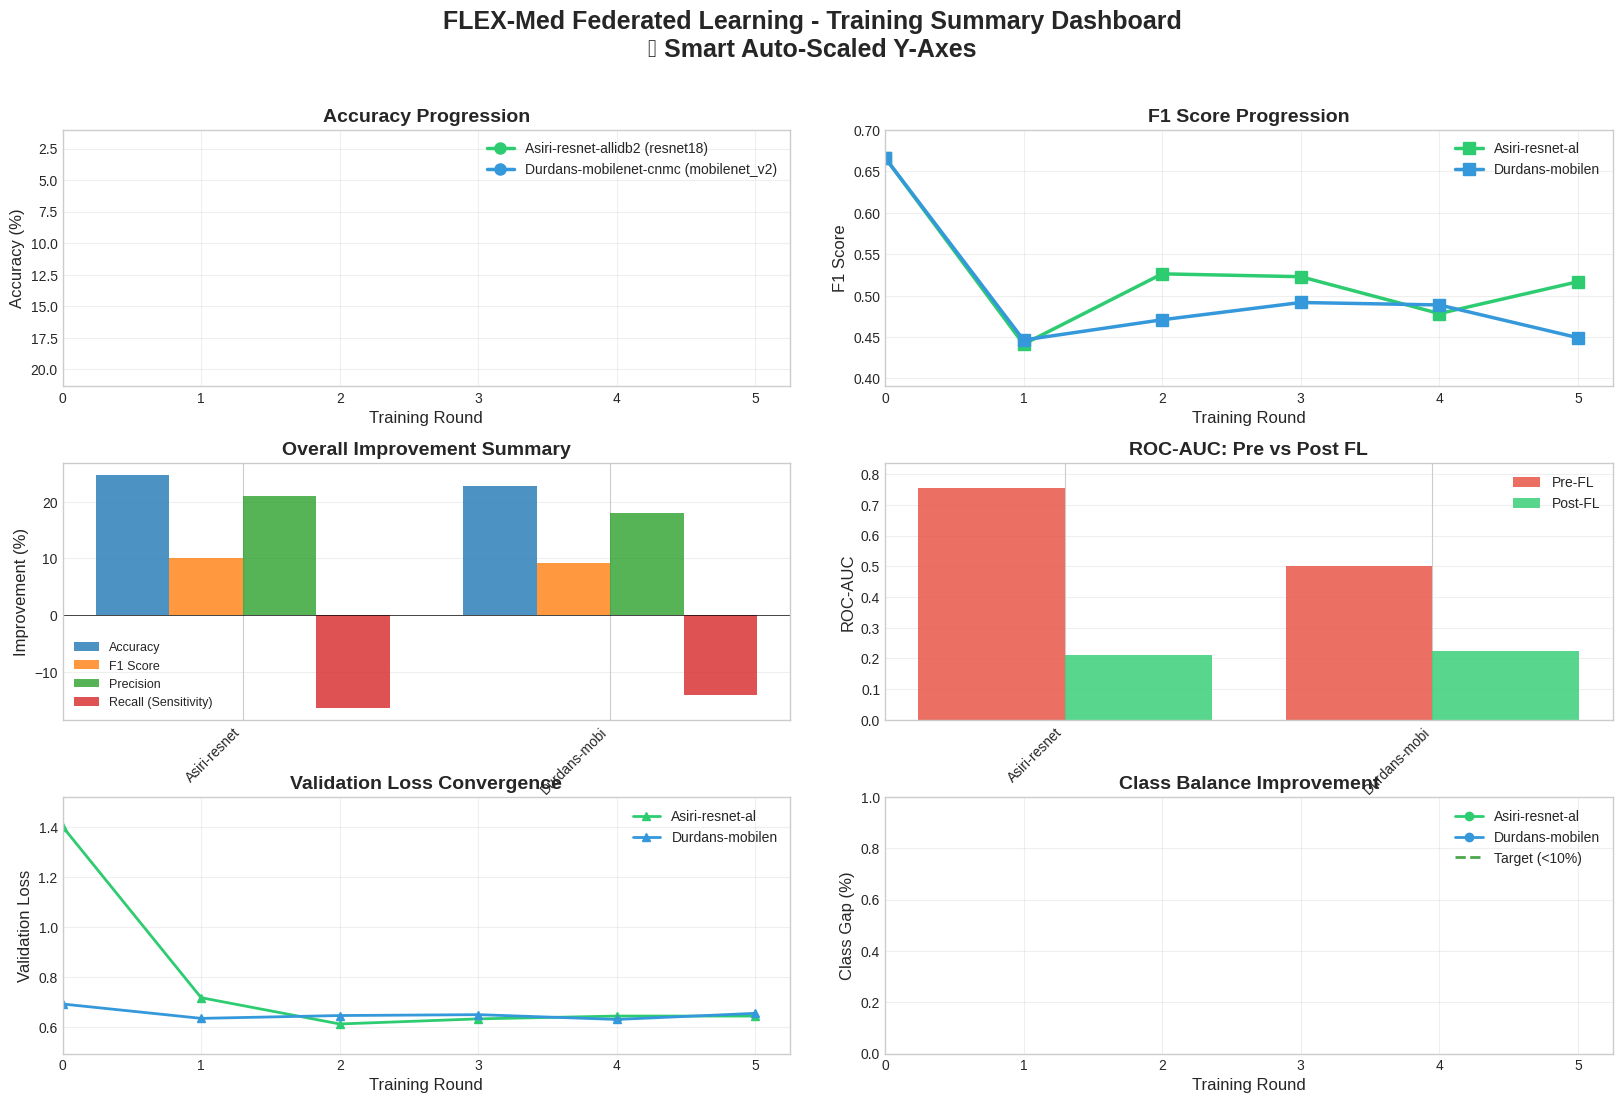

  Saved: summary_dashboard.png

2. Individual Metric Progressions


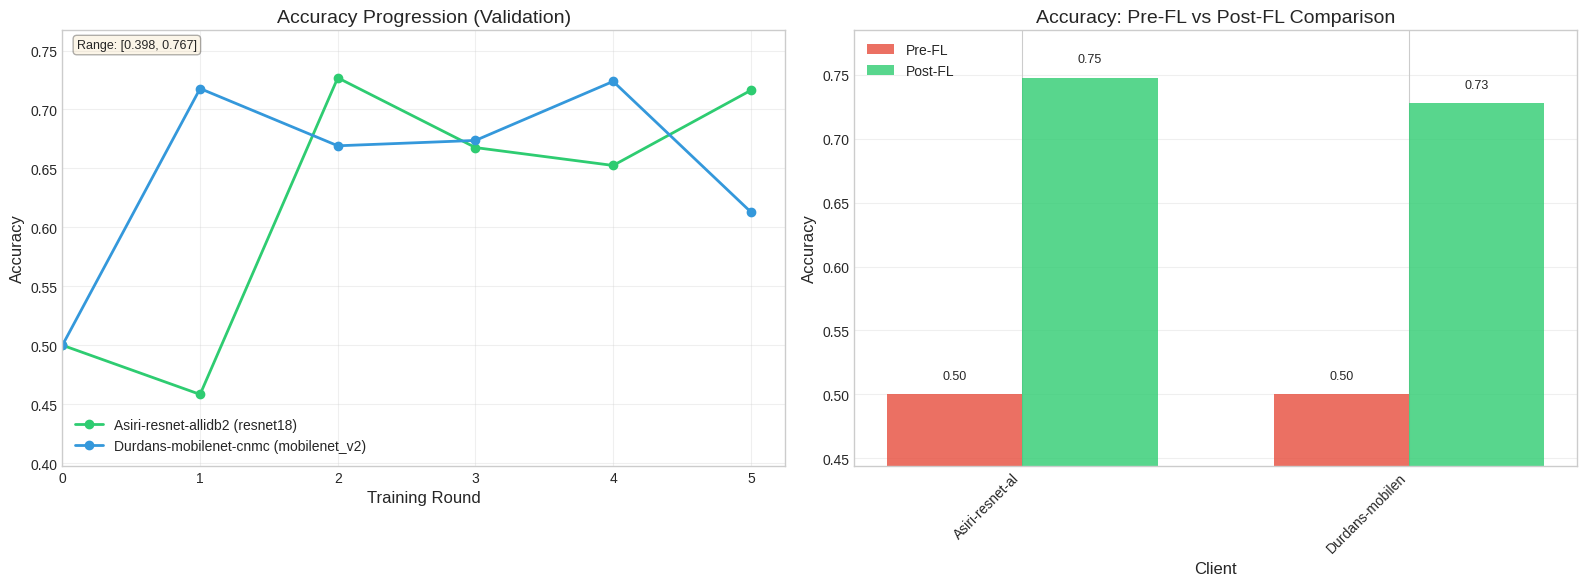

  Saved: accuracy_progression.png


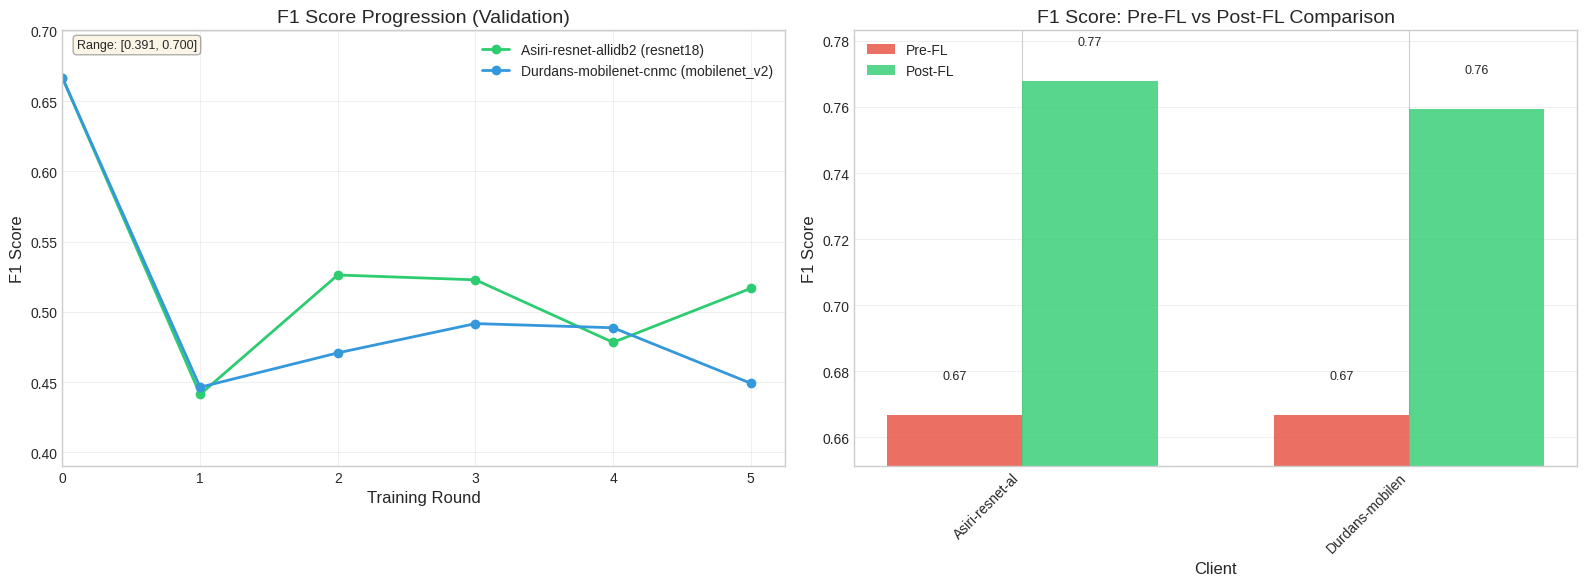

  Saved: f1_score_progression.png


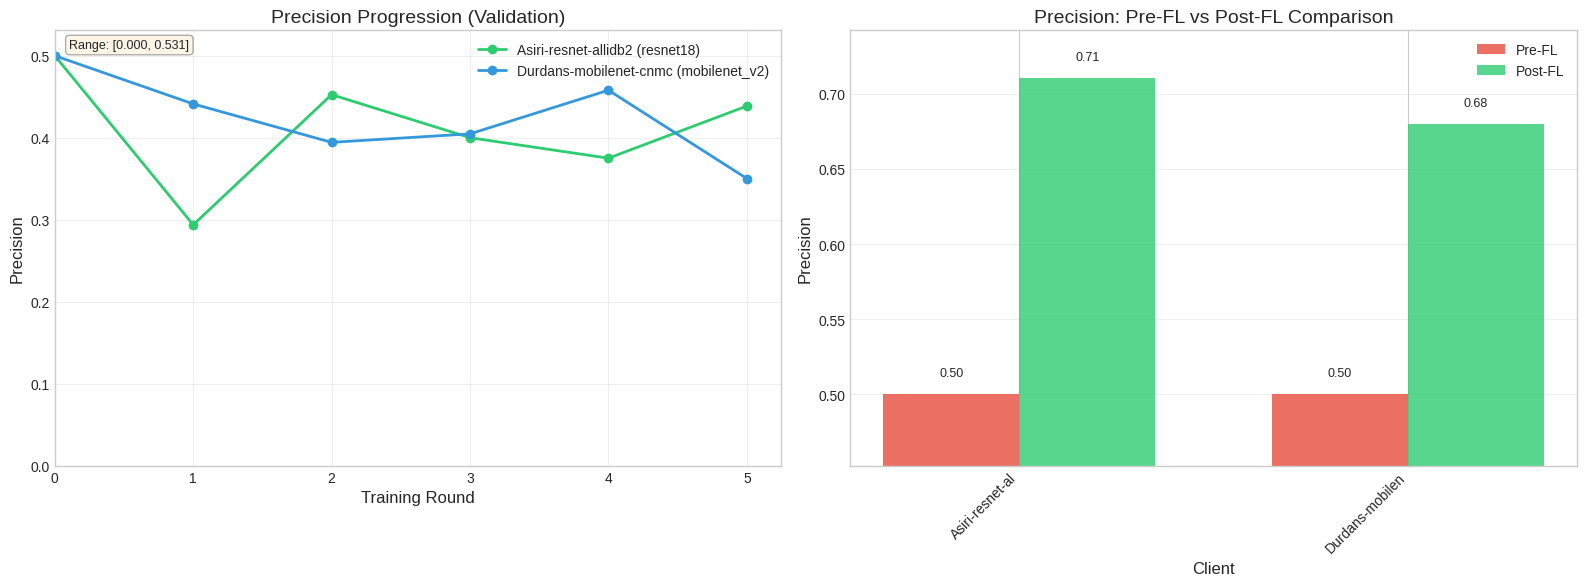

  Saved: precision_progression.png


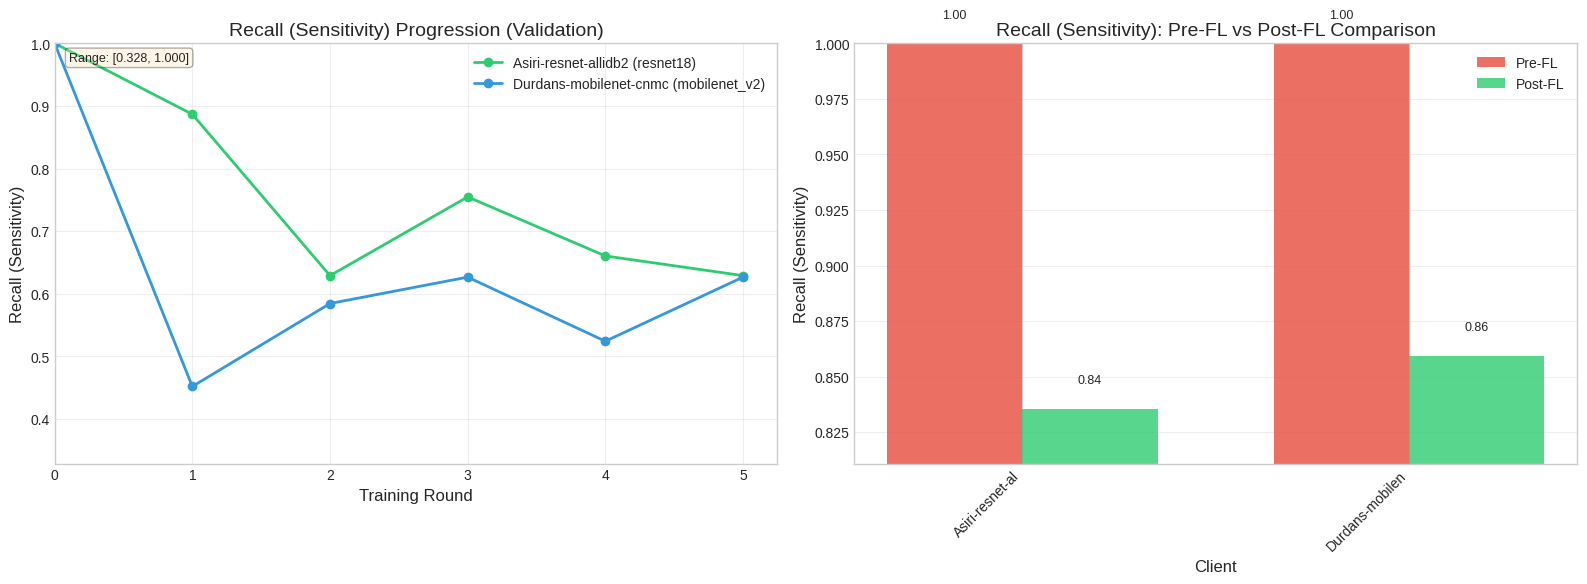

  Saved: recall_progression.png


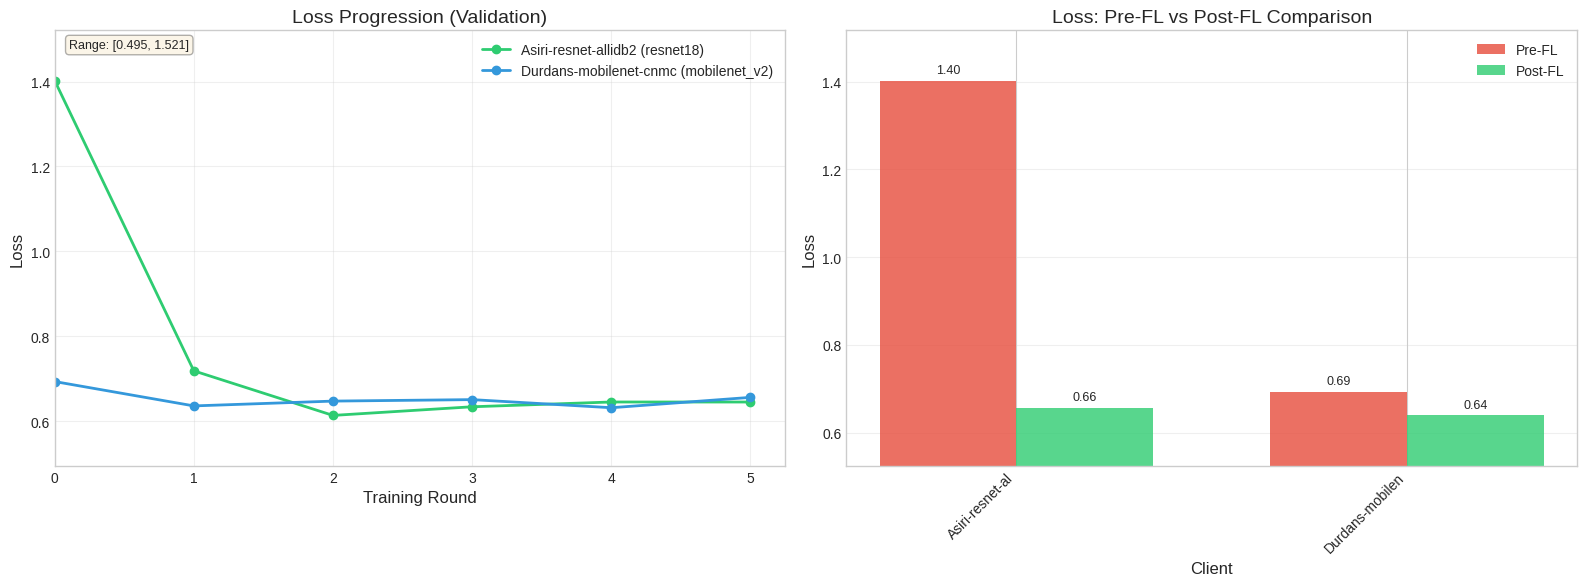

  Saved: loss_progression.png


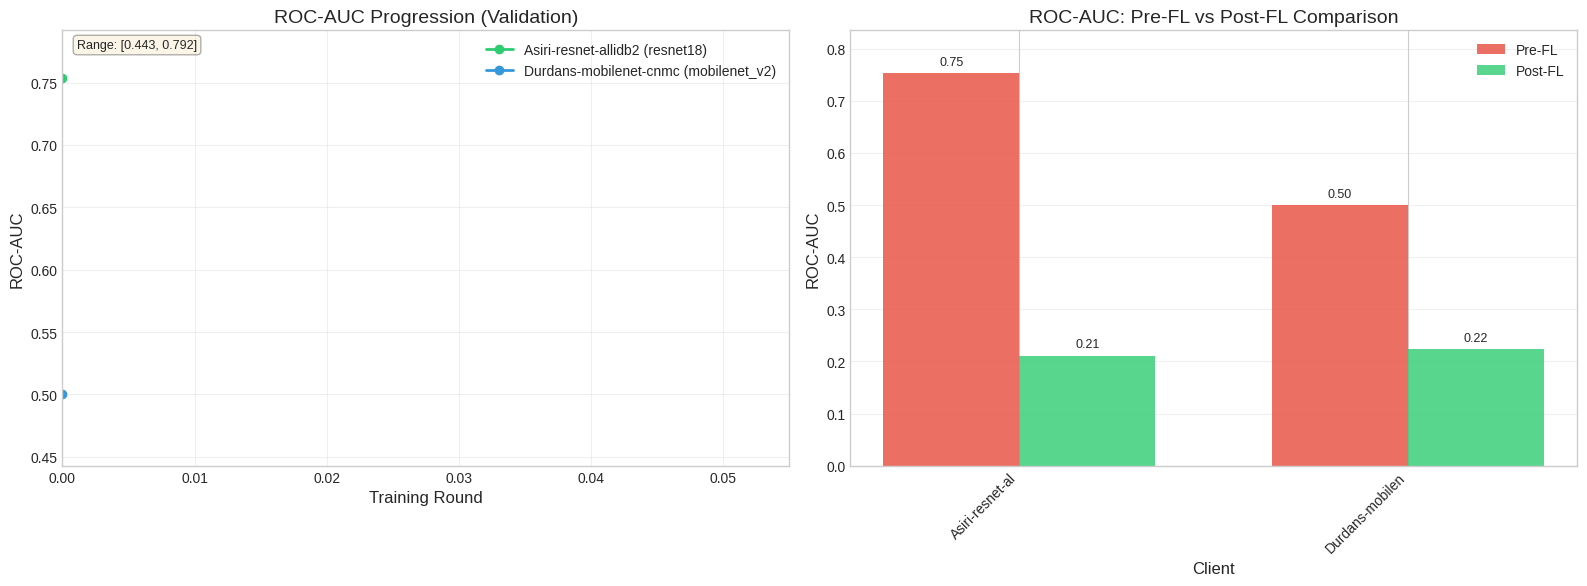

  Saved: roc_auc_progression.png

3. Improvement Analysis


UnboundLocalError: cannot access local variable 'ymax' where it is not associated with a value

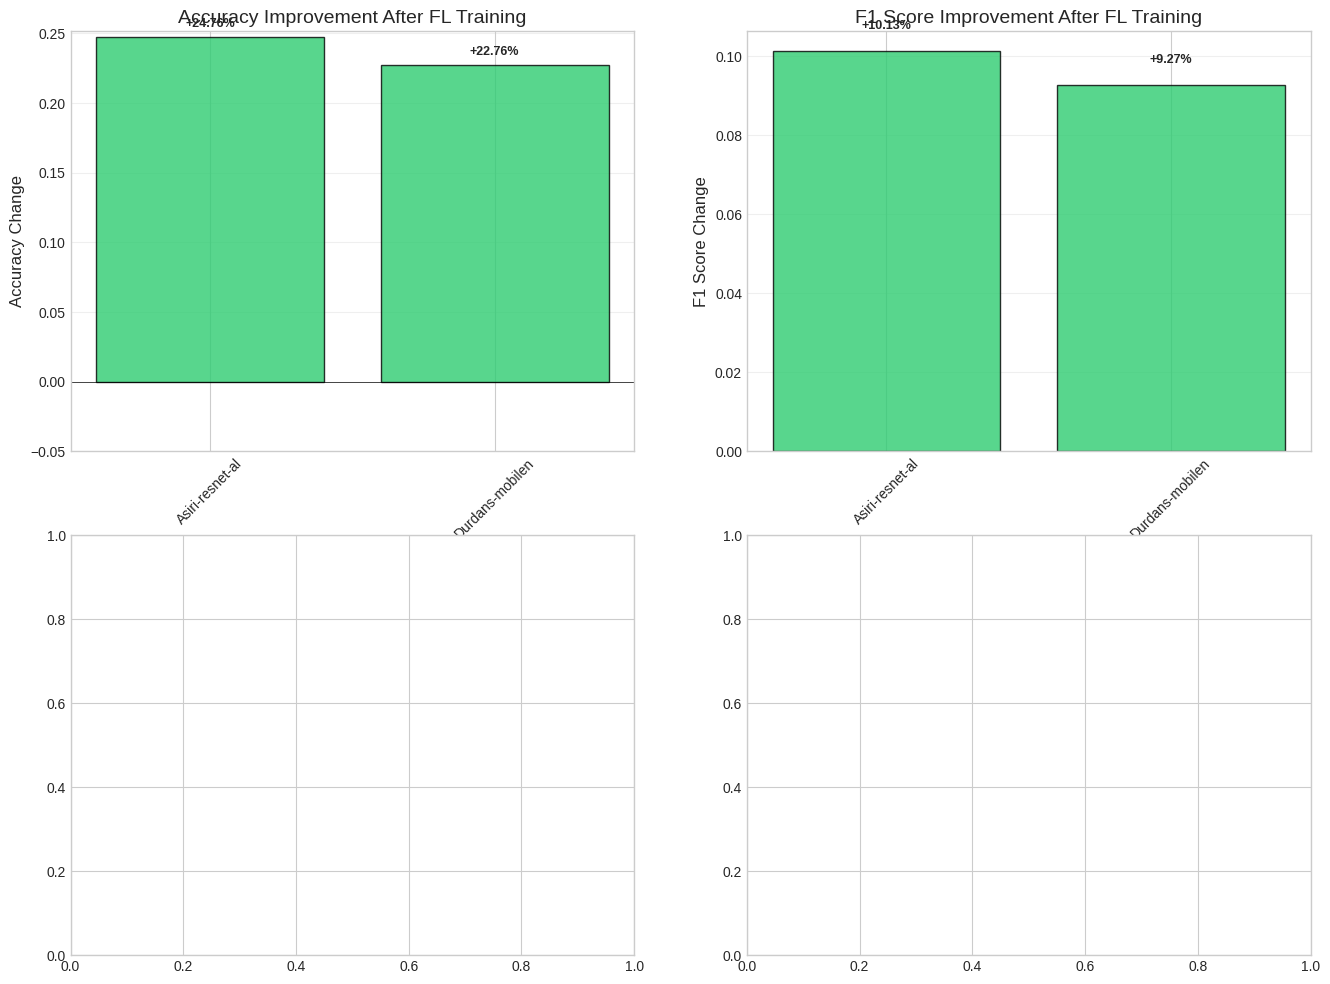

In [5]:
# ==========================================
# FL EVALUATION - GENERATE VISUALIZATIONS
# ==========================================
# This cell generates comprehensive graphical visualizations
# of the FL training metrics stored in cnmc_data.json

import sys
import os

# Ensure the project is in path
PROJECT_ROOT = "/content/drive/MyDrive/College/FLEX-Med/flex-med"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import the visualization module
from flex_med.utils.fl_evaluation import (
    generate_all_visualizations,
    print_metrics_summary,
    DATA_JSON_PATH,
    GRAPHS_OUTPUT_DIR
)

# Print summary first
print_metrics_summary()

# Generate all visualizations
print("\n")
saved_files = generate_all_visualizations(
    data_path=DATA_JSON_PATH,
    output_dir=GRAPHS_OUTPUT_DIR,
    show_plots=True  # Set to False if you only want to save, not display
)

print(f"\n📊 All visualizations saved to: {GRAPHS_OUTPUT_DIR}")